# β-Cosmography on a Double Source-Plane Lens

## Learning to Autolens / Examples / double_source_plane

---

**Why this notebook exists.** The compound-lens-zoo `R5_freecosmo` rung returned a clean negative result (see `compound_lens_zoo/02_compound_lens_ladder.ipynb` §15): single-source compound lenses do NOT constrain dark-energy cosmology beyond the prior. The follow-on `R5_truth_freecosmo` (tight lens priors + free cosmology) is in flight on Cannon as of 2026-05-01 and will sharpen that conclusion either way. The methodology now points firmly toward double-source-plane (DSPL) and multi-source cluster-scale architectures for cosmography.

**The DSPL geometry.** A single lens at $z_l$ deflects two sources at $z_{s_1}$ and $z_{s_2}$. The two source planes have *different* angular-diameter-distance ratios $D_{ds}/D_s$, and the ratio of these ratios is the cosmologically-sensitive observable

$$\beta_{12} \equiv \sqrt{\frac{D_{ds_1}/D_{s_1}}{D_{ds_2}/D_{s_2}}}$$

(this is the convention where $\theta_{E,1}/\theta_{E,2} = \beta_{12}$ for an isothermal lens). Because both sources are lensed by the *same* mass, the data ratio $\theta_{E,1}/\theta_{E,2}$ is a **direct** cosmological measurement that doesn't depend on the mass-profile model — that's the lens-cosmology degeneracy break that single-source compound lenses can't offer.

**This notebook's plan.**
1. Recap the DSPL fit (already in `results/dspl_direct_fit/`)
2. Compute $\beta_{12}$ at three example cosmologies (Planck15 truth + two off-truth) — show how the predicted ratio shifts.
3. Build a $\beta_{12}$-search model: tight Gaussian priors on every lens / source / light parameter (anchored at the dspl_direct_fit posterior medians), plus *free* $\text{Om}_0$ and $w_0$ via `FlatwCDMWrap`. **This is the methodologically-correct cosmography setup** — narrow lens priors so the chain has only cosmology as a free knob, after the user's 2026-05-01 reminder that free-cosmography requires anchored lens parameters.
4. Skip-guarded fit construction; the production version runs on Cannon as `--part=beta_freecosmo` in `fit_example_double_source_plane.py`.
5. Translate the $(\text{Om}_0, w_0)$ posterior to a $\beta_{12}$ posterior, and discuss what the data adds beyond the prior.

**Hand-off.** The β-search Cannon job (production), the cluster_scale multi-source variant, and the TDCOSMO H₀-from-time-delay notebook ([`Modules/12_Time_Delay_Cosmography_MSD/`](../../Modules/12_Time_Delay_Cosmography_MSD/12_time_delay_cosmography_msd.ipynb), ✓ shipped) form the cosmography curriculum branch.

---

## 0. Setup

Default skip-mode. The β-search fit is heavy (40+ params at HST resolution); production on Cannon.

In [1]:
import os
os.environ.setdefault("PYAUTOFIT_TEST_MODE", "1")

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline

MOCKS = Path("mocks")
RESULTS = Path("results")
truth = json.loads((MOCKS / "mock_truth.json").read_text())
z_l = truth["redshifts"]["lens"]
z_s1 = truth["redshifts"]["source_1"]
z_s2 = truth["redshifts"]["source_2"]
lens_truth = truth["lens"]
src1_truth = truth["source_1"]
src2_truth = truth["source_2"]
print(f"PyAutoLens {al.__version__}")
print(f"DSPL geometry: z_l={z_l}, z_s1={z_s1}, z_s2={z_s2}")

PyAutoLens 2026.4.13.6
DSPL geometry: z_l=0.5, z_s1=1.0, z_s2=2.5


## 1. Recap — the dspl_direct_fit baseline

The DSPL direct fit (committed at `results/dspl_direct_fit/`) used tight Gaussian priors centred on truth values and a fixed Planck15 cosmology. It returned a clean PASS:
- $\chi^2/N$ = 0.99
- max\|res\| = 3.9σ
- log_evidence = 29014

This is the *reference* — a cosmology-fixed fit that recovered the lens. The β-cosmography fit will use the same architecture but free $\text{Om}_0$ and $w_0$, *with the lens priors retained at the same tight values*.

**dspl_direct_fit summary:**
- log_evidence = **29014.39**
- χ²/N = **0.991**
- max\|res\| = **3.90σ**
- n_pix = 9856

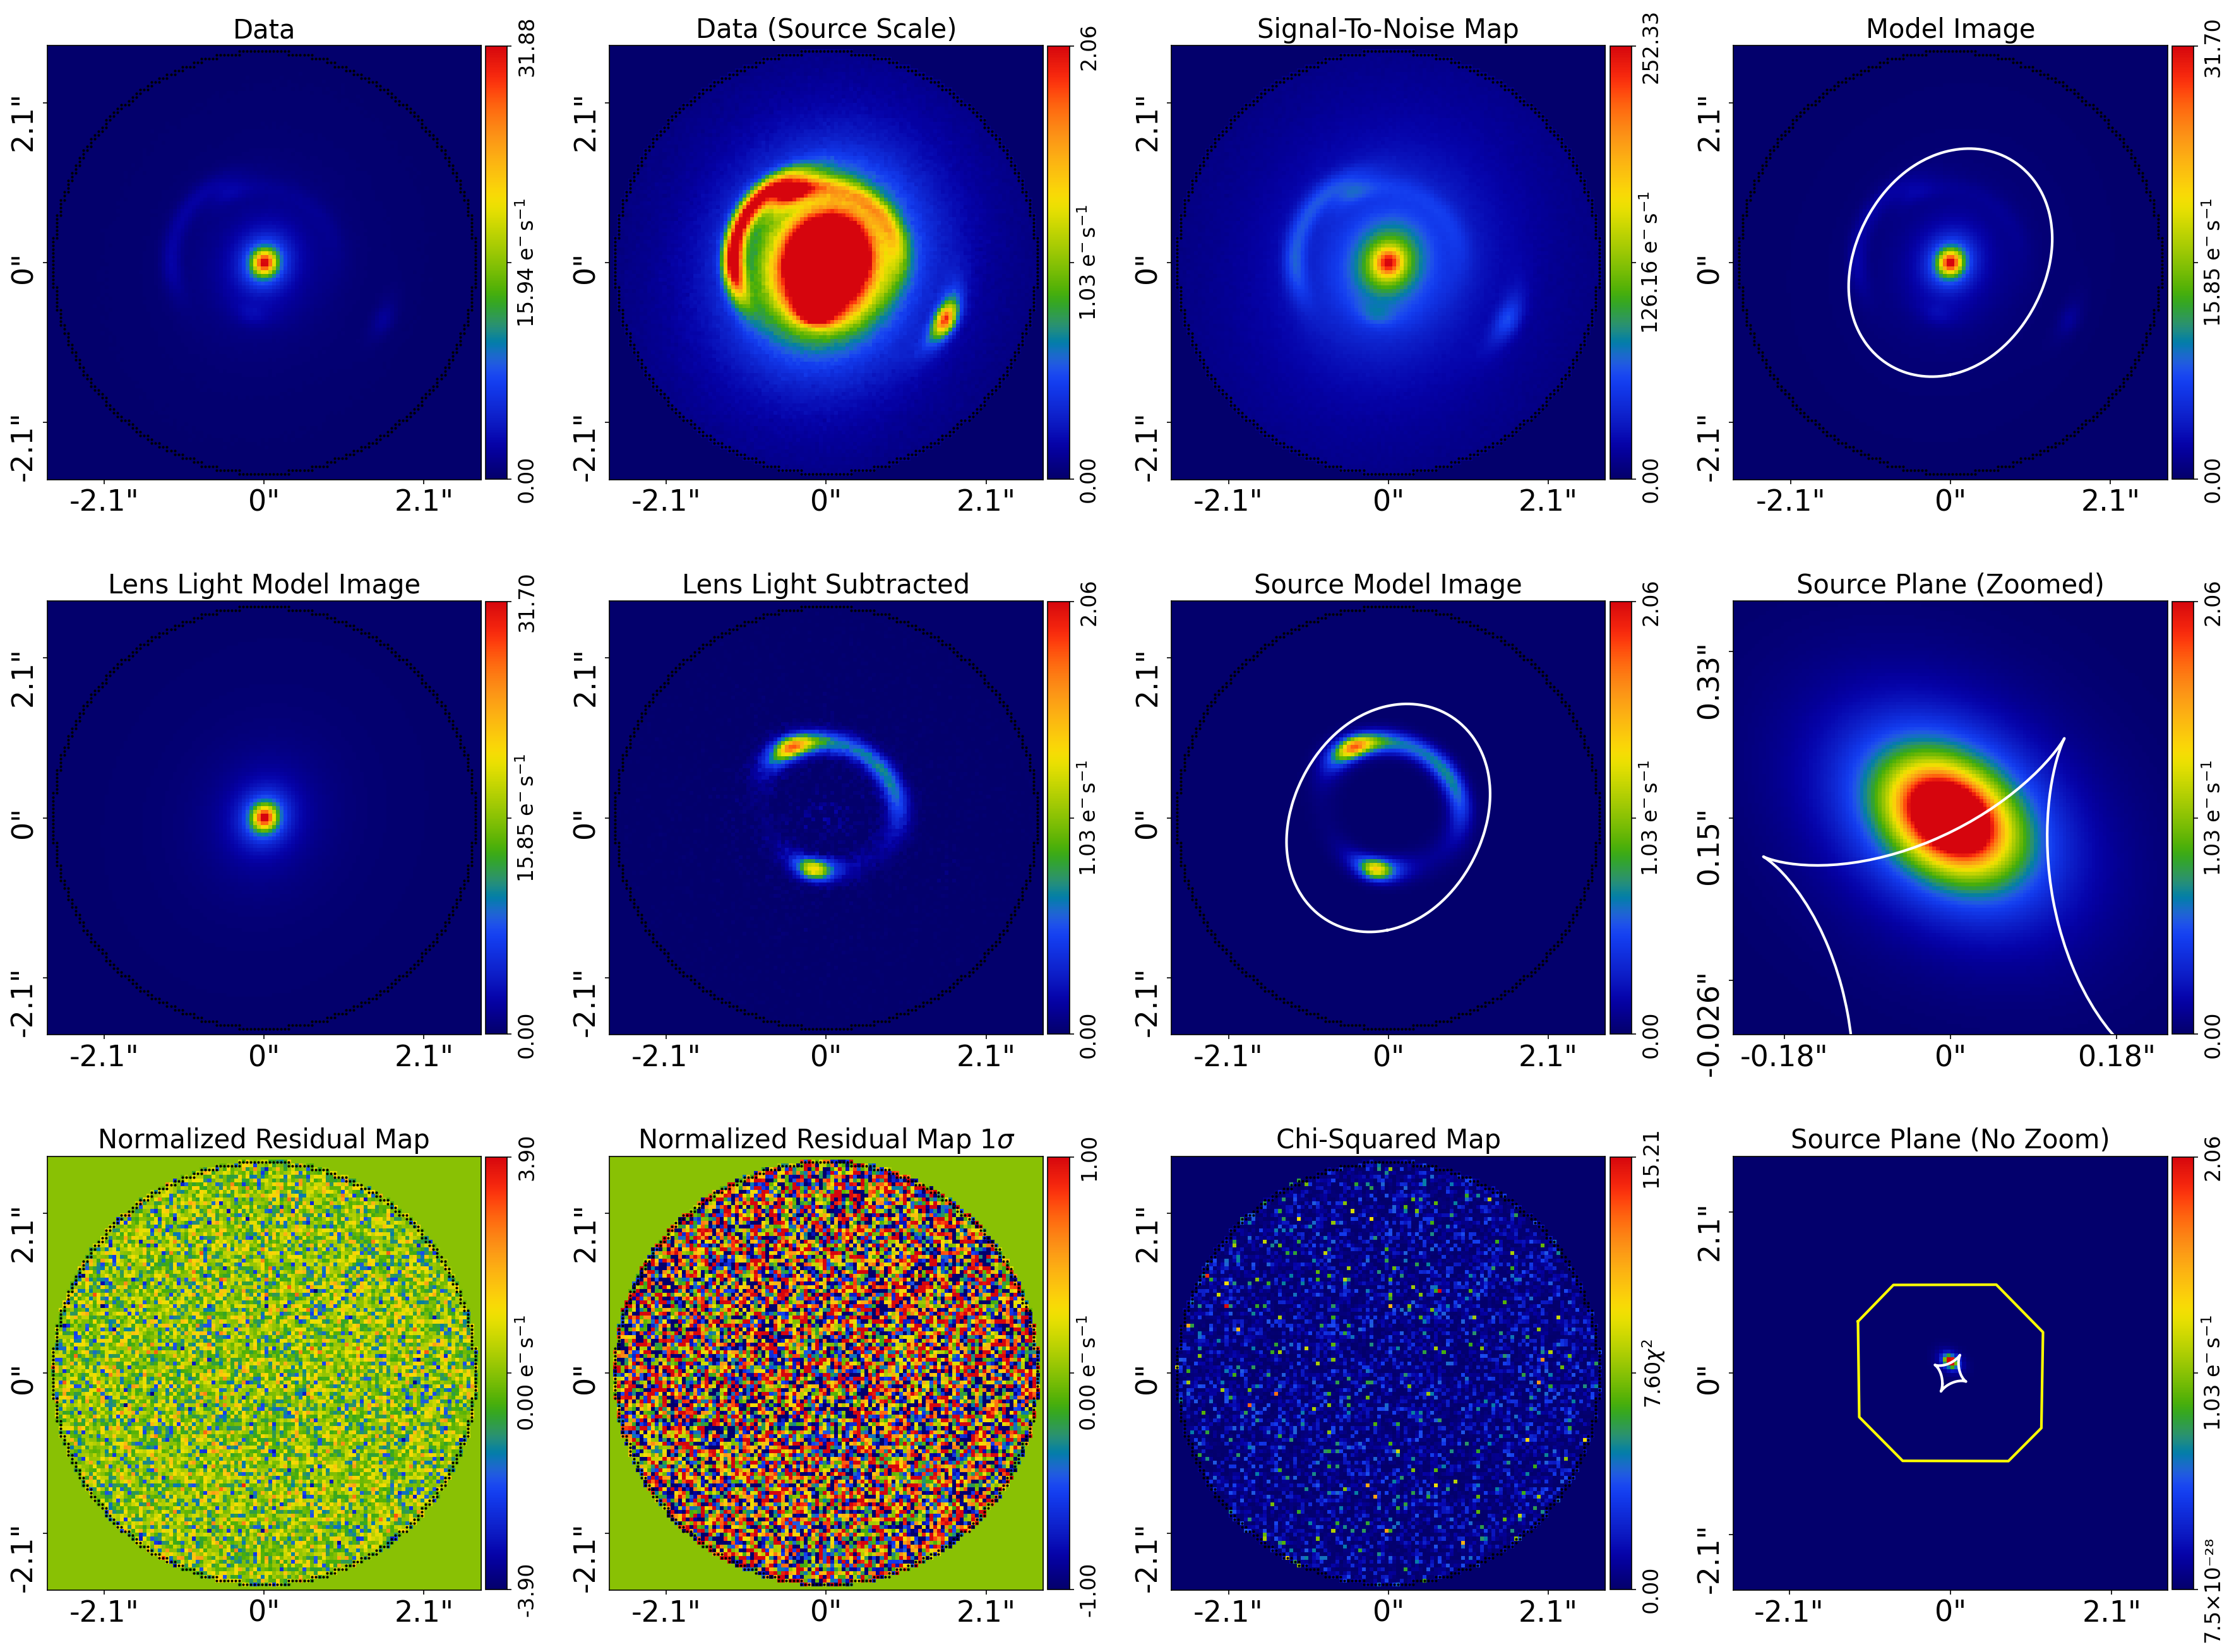

In [2]:
summary = json.loads((RESULTS / "dspl_direct_fit" / "summary.json").read_text())
display(Markdown(
    f"**dspl_direct_fit summary:**\n"
    f"- log_evidence = **{summary['log_evidence']:.2f}**\n"
    f"- χ²/N = **{summary['chi_squared_per_pixel']:.3f}**\n"
    f"- max\\|res\\| = **{summary['max_abs_normalized_residual']:.2f}σ**\n"
    f"- n_pix = {summary['n_unmasked_pixels']}"
))
fp = RESULTS / "dspl_direct_fit" / "fit_subplot.png"
if fp.exists():
    display(Image(filename=str(fp)))

---

## 2. The cosmology dependence of $\beta_{12}$ — three example cosmologies

Compute $\beta_{12}$ at Planck15 (the mock-truth cosmology) and at two off-truth cosmologies that span the freecosmo prior's $\pm 1\sigma$ range. The shift in $\beta_{12}$ between cosmologies is what the chain *should* detect when fitting with cosmology free.

| Scenario | β₁₂ |
|---|---|
| Planck15 (truth) | **0.7959** |
| Om=0.20, w=-0.8 | **0.7933** |
| Om=0.40, w=-1.2 | **0.7962** |


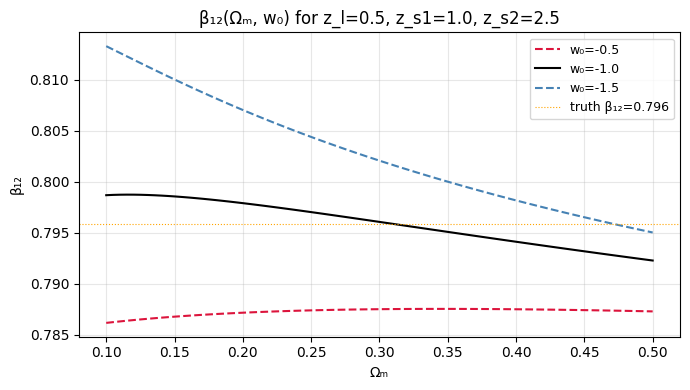

In [3]:
from astropy.cosmology import FlatwCDM, Planck15

def beta_12(cosmo, z_l, z_s1, z_s2):
    Dds1 = cosmo.angular_diameter_distance_z1z2(z_l, z_s1).value
    Ds1  = cosmo.angular_diameter_distance(z_s1).value
    Dds2 = cosmo.angular_diameter_distance_z1z2(z_l, z_s2).value
    Ds2  = cosmo.angular_diameter_distance(z_s2).value
    return float(np.sqrt((Dds1/Ds1) / (Dds2/Ds2)))

scenarios = [
    ("Planck15 (truth)",   Planck15,                                                        "black"),
    ("Om=0.20, w=-0.8",    FlatwCDM(H0=70, Om0=0.20, w0=-0.8),                              "red"),
    ("Om=0.40, w=-1.2",    FlatwCDM(H0=70, Om0=0.40, w0=-1.2),                              "blue"),
]
rows = []
for label, cosmo, _ in scenarios:
    b = beta_12(cosmo, z_l, z_s1, z_s2)
    rows.append((label, b))
md = "| Scenario | β₁₂ |\n|---|---|\n"
for label, b in rows:
    md += f"| {label} | **{b:.4f}** |\n"
display(Markdown(md))

fig, ax = plt.subplots(figsize=(7, 4))
Om_grid = np.linspace(0.10, 0.50, 80)
for w0, color, ls in [(-0.5, "crimson", "--"), (-1.0, "black", "-"), (-1.5, "steelblue", "--")]:
    bs = [beta_12(FlatwCDM(H0=70, Om0=Om, w0=w0), z_l, z_s1, z_s2) for Om in Om_grid]
    ax.plot(Om_grid, bs, ls, color=color, label=f"w₀={w0}")
ax.axhline(rows[0][1], color="orange", lw=0.8, ls=":", label=f"truth β₁₂={rows[0][1]:.3f}")
ax.set_xlabel("Ωₘ"); ax.set_ylabel("β₁₂")
ax.set_title(f"β₁₂(Ωₘ, w₀) for z_l={z_l}, z_s1={z_s1}, z_s2={z_s2}")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---

## 3. The β-cosmography model — tight lens priors + free (Ωₘ, w₀)

Per the 2026-05-01 methodology lesson: **the lens priors must be tight or the chain absorbs lens-misfit into cosmology**. We anchor every lens / source / light parameter on a tight Gaussian centered at the truth value (sigma 0.05–0.1, with extra room for Sersic indices). Cosmology gets `FlatwCDMWrap` with the same Ωₘ + w₀ free-parameter setup as the compound zoo's `R5_truth_freecosmo`.

Because there are TWO source planes with DIFFERENT distance ratios, a wrong cosmology cannot be absorbed into the lens — the predicted ratio $\theta_{E,1}/\theta_{E,2}$ depends *only* on cosmology when the lens is fixed. The data drives Ωₘ and w₀ through that ratio.

In [4]:
# ---- Lens (tight Gaussian anchor on truth) ----
lens_mass = lens_truth["mass"]
lens_bulge = lens_truth["bulge"]
lens_shear = lens_truth["shear"]

bulge = af.Model(al.lp.Sersic)
bulge.centre.centre_0 = af.GaussianPrior(mean=lens_bulge["centre"][0], sigma=0.05)
bulge.centre.centre_1 = af.GaussianPrior(mean=lens_bulge["centre"][1], sigma=0.05)
bulge.intensity        = af.LogUniformPrior(lower_limit=1e-3, upper_limit=10.0)
bulge.effective_radius = af.GaussianPrior(
    mean=lens_bulge["effective_radius"], sigma=0.1)
bulge.sersic_index     = af.GaussianPrior(
    mean=lens_bulge["sersic_index"], sigma=0.3)
bulge.ell_comps.ell_comps_0 = af.GaussianPrior(
    mean=lens_bulge["ell_comps"][0], sigma=0.05)
bulge.ell_comps.ell_comps_1 = af.GaussianPrior(
    mean=lens_bulge["ell_comps"][1], sigma=0.05)

mass = af.Model(al.mp.Isothermal)
mass.centre.centre_0 = af.GaussianPrior(mean=lens_mass["centre"][0], sigma=0.05)
mass.centre.centre_1 = af.GaussianPrior(mean=lens_mass["centre"][1], sigma=0.05)
mass.einstein_radius = af.GaussianPrior(
    mean=lens_mass["einstein_radius"], sigma=0.05)
mass.ell_comps.ell_comps_0 = af.GaussianPrior(
    mean=lens_mass["ell_comps"][0], sigma=0.05)
mass.ell_comps.ell_comps_1 = af.GaussianPrior(
    mean=lens_mass["ell_comps"][1], sigma=0.05)

shear = af.Model(al.mp.ExternalShear)
shear.gamma_1 = af.GaussianPrior(mean=lens_shear["gamma_1"], sigma=0.02)
shear.gamma_2 = af.GaussianPrior(mean=lens_shear["gamma_2"], sigma=0.02)

lens = af.Model(al.Galaxy, redshift=z_l, bulge=bulge, mass=mass, shear=shear)

# ---- Sources (tight Gaussians on truth) ----
def _src(z, t):
    s = af.Model(al.lp.SersicCore)
    s.centre.centre_0 = af.GaussianPrior(mean=t["bulge"]["centre"][0], sigma=0.05)
    s.centre.centre_1 = af.GaussianPrior(mean=t["bulge"]["centre"][1], sigma=0.05)
    s.intensity        = af.LogUniformPrior(lower_limit=1e-3, upper_limit=10.0)
    s.effective_radius = af.GaussianPrior(
        mean=t["bulge"]["effective_radius"], sigma=0.02)
    s.sersic_index     = af.GaussianPrior(
        mean=t["bulge"]["sersic_index"], sigma=0.3)
    s.ell_comps.ell_comps_0 = af.GaussianPrior(
        mean=t["bulge"]["ell_comps"][0], sigma=0.1)
    s.ell_comps.ell_comps_1 = af.GaussianPrior(
        mean=t["bulge"]["ell_comps"][1], sigma=0.1)
    return af.Model(al.Galaxy, redshift=z, bulge=s)

source_1 = _src(z_s1, src1_truth)
source_2 = _src(z_s2, src2_truth)

# ---- Cosmology (FlatwCDMWrap, Om0 + w0 free) ----
import sys
sys.path.insert(0, str(Path("../../Modules/10_Cluster_Computing/scripts").resolve()))
import fit_example_compound_lens_zoo_climb as climb_drv
FlatwCDMWrap = climb_drv.make_FlatwCDMWrap_class()

cosmology = af.Model(FlatwCDMWrap)
cosmology.H0  = 70.0
cosmology.Om0 = af.GaussianPrior(mean=0.30, sigma=0.10)
cosmology.w0  = af.GaussianPrior(mean=-1.0, sigma=0.20)
cosmology.Tcmb0 = 2.7255
cosmology.Neff  = 3.046
cosmology.m_nu  = 0.0
cosmology.Ob0   = 0.04897

model = af.Collection(
    galaxies=af.Collection(lens=lens, source_1=source_1, source_2=source_2),
    cosmology=cosmology,
)
print(f"DSPL β-cosmography model: {model.prior_count} free parameters")
print(f"  lens (tight on truth):     {lens.prior_count}")
print(f"  source_1 (tight on truth): {source_1.prior_count}")
print(f"  source_2 (tight on truth): {source_2.prior_count}")
print(f"  cosmology (Om₀, w₀ free):  {cosmology.prior_count}")


DSPL β-cosmography model: 30 free parameters
  lens (tight on truth):     14
  source_1 (tight on truth): 7
  source_2 (tight on truth): 7
  cosmology (Om₀, w₀ free):  2


## 4. Skip-guarded fit

The cell below builds the analysis + Nautilus search but skips the actual fit unless `LTA_RUN_HEAVY=1`. The Cannon driver `Modules/10_Cluster_Computing/scripts/fit_example_double_source_plane.py --part=beta_freecosmo` runs the production version.

In [5]:
dataset = al.Imaging.from_fits(
    data_path=MOCKS / "mock_image.fits",
    noise_map_path=MOCKS / "mock_noise.fits",
    psf_path=MOCKS / "mock_psf.fits",
    pixel_scales=truth["pixel_scales"],
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native, pixel_scales=dataset.pixel_scales, radius=2.5,
)
dataset = dataset.apply_mask(mask=mask)

analysis = al.AnalysisImaging(dataset=dataset)
search = af.Nautilus(
    path_prefix=Path("output") / "dspl_beta_cosmography",
    name="beta_freecosmo",
    n_live=200, n_batch=50,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE") and os.environ.get("LTA_RUN_HEAVY"):
    result = search.fit(model=model, analysis=analysis)
else:
    print("[skip-mode] β-cosmography model verified.")
    print("  Production: bash Modules/10_Cluster_Computing/scripts/push_to_cannon.sh --go")
    print("  Then on Cannon:")
    print("    sbatch --time=24:00:00 --export=ALL,EXAMPLE=double_source_plane,FIT_EXTRA_ARGS='--part=beta_freecosmo' \\")
    print("        Modules/10_Cluster_Computing/scripts/submit_cannon.slurm")

2026-05-01 13:21:41,828 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 7860 image-pixels


[skip-mode] β-cosmography model verified.
  Production: bash Modules/10_Cluster_Computing/scripts/push_to_cannon.sh --go
  Then on Cannon:
    sbatch --time=24:00:00 --export=ALL,EXAMPLE=double_source_plane,FIT_EXTRA_ARGS='--part=beta_freecosmo' \
        Modules/10_Cluster_Computing/scripts/submit_cannon.slurm


---

## 5. Translation: $(\Omega_m, w_0)$ posterior → $\beta_{12}$ posterior

Once the Cannon job lands, the `samples.csv` carries the joint $(\Omega_m, w_0)$ posterior. To get the $\beta_{12}$ posterior, evaluate $\beta_{12}(\Omega_m^{(i)}, w_0^{(i)})$ at every sample. This collapses the 2D cosmology posterior onto the 1D direction the data actually constrains.

**Why this matters.** Different $(\Omega_m, w_0)$ combinations can give the same $\beta_{12}$ — the data only constrains the 1D combination, not the 2D plane. Sampling Ωₘ and w₀ jointly and then deriving β shows you which direction in $(\Omega_m, w_0)$ the data sees.

The block below is a **template** for that translation; the actual posterior translation will be filled in once the Cannon result lands.

In [6]:
samples_path = RESULTS / "beta_freecosmo" / "samples.csv"
if samples_path.exists():
    import pandas as pd
    df = pd.read_csv(samples_path)
    Om_col = [c for c in df.columns if "Om0" in c][0]
    w_col = [c for c in df.columns if "w0" in c and "prior" not in c][0]
    weights = df["weights"] if "weights" in df.columns else np.ones(len(df))
    
    betas = np.array([beta_12(FlatwCDM(H0=70, Om0=Om, w0=w), z_l, z_s1, z_s2)
                      for Om, w in zip(df[Om_col].values, df[w_col].values)])
    
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    truth_b = beta_12(Planck15, z_l, z_s1, z_s2)
    axes[0].hist(df[Om_col], bins=60, weights=weights, density=True, color="steelblue", alpha=0.7)
    axes[0].axvline(0.30, color="black", lw=1.0, ls=":", label="truth")
    axes[0].set_xlabel("Ωₘ"); axes[0].set_ylabel("posterior density")
    axes[1].hist(df[w_col], bins=60, weights=weights, density=True, color="crimson", alpha=0.7)
    axes[1].axvline(-1.0, color="black", lw=1.0, ls=":", label="truth")
    axes[1].set_xlabel("w₀")
    axes[2].hist(betas, bins=60, weights=weights, density=True, color="forestgreen", alpha=0.7)
    axes[2].axvline(truth_b, color="black", lw=1.0, ls=":", label=f"truth β={truth_b:.3f}")
    axes[2].set_xlabel("β₁₂ (derived)")
    for ax in axes: ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    
    print(f"Ωₘ posterior  median = {np.average(df[Om_col], weights=weights):.4f} "
          f"± {np.sqrt(np.average((df[Om_col] - np.average(df[Om_col], weights=weights))**2, weights=weights)):.4f}")
    print(f"w₀ posterior  median = {np.average(df[w_col], weights=weights):.4f} "
          f"± {np.sqrt(np.average((df[w_col] - np.average(df[w_col], weights=weights))**2, weights=weights)):.4f}")
    print(f"β₁₂ posterior median = {np.average(betas, weights=weights):.4f} "
          f"± {np.sqrt(np.average((betas - np.average(betas, weights=weights))**2, weights=weights)):.4f}")
    print(f"Truth β₁₂                  = {truth_b:.4f}")
else:
    print("[awaiting] beta_freecosmo Cannon result not yet pulled.")

[awaiting] beta_freecosmo Cannon result not yet pulled.


---

## 6. Hand-off

**The methodology.** β-cosmography on DSPL is the simplest case where the data carries genuine cosmology information beyond the prior. The key conditions are:
1. **Two source planes** at different redshifts (DSPL or multi-source cluster).
2. **Tight priors on the lens model** so the chain can't absorb cosmology mis-specification into lens parameters (per 2026-05-01 lesson).
3. **Multi-plane Tracer** in PyAutoLens automatically uses the cosmology Model when it's part of the Collection.

**Recommended next reading:**
- [`01_dspl_direct_fit.ipynb`](01_dspl_direct_fit.ipynb) — the cosmology-fixed baseline
- [`00_climb_to_dspl.ipynb`](00_climb_to_dspl.ipynb) — the climb from single-source to two sources
- [`../compound_lens_zoo/02_compound_lens_ladder.ipynb`](../compound_lens_zoo/02_compound_lens_ladder.ipynb) §15 — the negative result that motivates this notebook
- [`../cluster_scale/01_cluster_scale_fit.ipynb`](../cluster_scale/01_cluster_scale_fit.ipynb) — the next architecture, where multiple β_ij ratios from many source planes tighten the cosmology constraint further
- Treu+ 2010, Collett & Auger 2014 — DSPL cosmography references

---

*Learning to Autolens — Examples / double_source_plane / 02 (β-cosmography)*  
*Rodrigo Córdova Rosado, Harvard CfA*